##Childhood Anemia in Nigeria: Statistical Analysis and Machine Learning

##An exploratory analysis of socioeconomic, geographic and behavioral factors among children

Data source: DHS 2024
Study population: Children with available anemia measurements

Analytical approach: Descriptive statistics · Chi-square tests · Logistic Regression · Random Forest

##Abstract

This project investigates patterns of childhood anemia in Nigeria using demographic, socioeconomic, geographic and selected behavioral characteristics. The analysis combines descriptive statistics, chi-square tests of association and machine learning classification. Among 27,783 records, 11,053 children had available anemia measurements. Of these tested children, 47.7% were classified as anemic. Anemia prevalence varied significantly across wealth groups, geographic zones and urban/rural residence. Logistic Regression and Random Forest models demonstrated limited predictive performance, with AUC values of approximately 0.56–0.57. The analysis also identified substantial variation in anemia testing coverage, highlighting an important consideration when interpreting prevalence estimates. The findings illustrate the distinction between population-level association and individual-level prediction.

##Background

Childhood anemia is an important health concern because it can affect children's growth, development, and overall well-being. Understanding the factors associated with anemia is therefore important for identifying populations that may be more affected and for supporting evidence-based public health planning.

Socioeconomic and demographic characteristics such as household wealth, geographic location, place of residence, and other household or child-level factors may be associated with differences in anemia prevalence. However, identifying population-level associations does not necessarily mean that these characteristics can accurately predict anemia at the individual level.

##Problem Statement

Childhood anemia remains an important public health issue, yet the distribution of anemia may differ across socioeconomic and geographic groups. Describing these differences is useful, but it is also important to determine whether commonly available demographic, socioeconomic, and behavioral characteristics provide sufficient information to identify children who are likely to be anemic.

##Aim
To examine anemia and related household/behavioral factors as indirect indicators of malaria risk among children under five in Nigeria, using data from the 2024 NDHS.

##Objectives

1.Determine the overall prevalence of anemia among tested children under five.

2.Examine variation in anemia prevalence across geopolitical zones, wealth quintiles, and urban/rural residence.

3.Assess the relationship between bed net ownership/use and anemia.

4.Assess the relationship between recent fever history and anemia.

## Research Questions
1.What proportion of tested children under five in Nigeria show signs of anemia?

2.Does anemia prevalence vary by geopolitical zone?

3.Is there a relationship between household wealth and anemia?

4.Does bed net ownership/use appear associated with lower anemia prevalence

## Methodology and Analytical Approach.

This study uses a cross-sectional analytical approach based on 2024 DHS data to investigate factors associated with childhood anemia in Nigeria.

Data: 27,783 child records were analyzed, of which 11,053 had available anemia measurements.

Outcome:Anemia was classified as a binary outcome: anemic (mild, moderate, or severe) vs. not anemic.

**Predictors:Geographic zone, wealth index, urban/rural residence, recent fever, bed-net use, household bed-net ownership, and birth order.

Analysis:

 Descriptive statistics and visualizations.

 Chi-square tests of association

 Logistic Regression

 Random Forest classification

 ROC-AUC, accuracy, precision, recall and F1-score

 Feature importance analysis


The analysis was conducted using Python, including Pandas, NumPy, SciPy, Matplotlib, Seaborn and Scikit-learn.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns
sns.set_style('whitegrid')

#Load the Dataset

In [8]:
df = pd.read_csv("/content/Nigeria_Malaria_DHS_data.csv")

In [9]:
#Number of rows and columns
print("shape:",df.shape)
df.head()
df.tail()

shape: (27783, 10)


,mother_id,birth_order,zone,urban_rural,wealth_index,had_fever,hh_net_ownership,child_net_use,anemia_level,child_id
27778,1400 7 3,1,South West,Rural,Richest,No,Yes,No net,Not tested,1400 7 3_1
27779,1400 16 1,1,South West,Rural,Poorer,No,No,No net,Not tested,1400 16 1_1
27780,1400 20 2,1,South West,Rural,Middle,No,No,No net,Not tested,1400 20 2_1
27781,1400 20 2,2,South West,Rural,Middle,No,No,Not asked / Not applicable,Not tested,1400 20 2_2
27782,1400 31 2,1,South West,Rural,Middle,No,Yes,Only treated nets,Not tested,1400 31 2_1


In [10]:
#Overview of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27783 entries, 0 to 27782
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   mother_id         27783 non-null  object
 1   birth_order       27783 non-null  int64 
 2   zone              27783 non-null  object
 3   urban_rural       27783 non-null  object
 4   wealth_index      27783 non-null  object
 5   had_fever         27783 non-null  object
 6   hh_net_ownership  27783 non-null  object
 7   child_net_use     27783 non-null  object
 8   anemia_level      27783 non-null  object
 9   child_id          27783 non-null  object
dtypes: int64(1), object(9)
memory usage: 2.1+ MB


In [11]:
#type of data in each column
print(df.dtypes)

mother_id           object
birth_order          int64
zone                object
urban_rural         object
wealth_index        object
had_fever           object
hh_net_ownership    object
child_net_use       object
anemia_level        object
child_id            object
dtype: object


In [12]:
#Checking every column for missing values/blank cells
print(df.isna().sum())

mother_id           0
birth_order         0
zone                0
urban_rural         0
wealth_index        0
had_fever           0
hh_net_ownership    0
child_net_use       0
anemia_level        0
child_id            0
dtype: int64


In [13]:
# Checking for duplicate values
print("duplicate child.id rows:",df['child_id'].duplicated().sum())

duplicate child.id rows: 0


In [14]:
#Value_count of each column
print(df["zone"].value_counts())

zone
North West       8599
North East       5892
North Central    5057
South East       3057
South South      2670
South West       2508
Name: count, dtype: int64


In [15]:
df.head()
df.tail()

,mother_id,birth_order,zone,urban_rural,wealth_index,had_fever,hh_net_ownership,child_net_use,anemia_level,child_id
27778,1400 7 3,1,South West,Rural,Richest,No,Yes,No net,Not tested,1400 7 3_1
27779,1400 16 1,1,South West,Rural,Poorer,No,No,No net,Not tested,1400 16 1_1
27780,1400 20 2,1,South West,Rural,Middle,No,No,No net,Not tested,1400 20 2_1
27781,1400 20 2,2,South West,Rural,Middle,No,No,Not asked / Not applicable,Not tested,1400 20 2_2
27782,1400 31 2,1,South West,Rural,Middle,No,Yes,Only treated nets,Not tested,1400 31 2_1


In [16]:
print(df["urban_rural"].value_counts())

urban_rural
Rural    17076
Urban    10707
Name: count, dtype: int64


In [17]:
print(df["wealth_index"].value_counts())

wealth_index
Poorest    7249
Poorer     5623
Middle     5381
Richer     5129
Richest    4401
Name: count, dtype: int64


In [18]:
print(df["had_fever"].value_counts())

had_fever
No                            21514
Yes                            3962
Not asked / Not applicable     2206
Don't know                      101
Name: count, dtype: int64


In [19]:
print(df["hh_net_ownership"].value_counts())

hh_net_ownership
Yes    19070
No      8713
Name: count, dtype: int64


In [20]:
print(df["child_net_use"].value_counts())

child_net_use
Not asked / Not applicable    14988
No net                         7265
Only treated nets              5446
Only untreated nets              81
Both treated and untreated        3
Name: count, dtype: int64


In [21]:
print(df["anemia_level"].value_counts())

anemia_level
Not tested    16730
Not anemic     5780
Mild           2785
Moderate       2393
Severe           95
Name: count, dtype: int64


In [22]:
print(df["child_id"].value_counts())

child_id
1400  31  2_1    1
   1   2  2_1    1
   1  10  2_1    1
   1  13  2_1    1
   1  19  2_1    1
                ..
   1  46  2_1    1
   1  43  2_1    1
   1  40  2_2    1
   1  40  2_1    1
   1  38  2_1    1
Name: count, Length: 27783, dtype: int64


##From the Dataset,no null value or duplicates were found but anemia_level,child_net_use and had_fever has categories like "Not asked/Not applicable", "Not tested" that function like missing data without being blank cells.

In [23]:
df["anemia_level"] = df["anemia_level"].fillna("Not tested")
df["anemia_level"].value_counts()

,count
anemia_level,
Not tested,16730
Not anemic,5780
Mild,2785
Moderate,2393
Severe,95


## anemia_level is only valid for children who were actually tested.Since we can't analyzed or predict a lab outcome for children not tested, I excluded it by filtering to the tested subset...

In [24]:
#keep children with anemia test result
#copy is used to avoid a warning sign when adding new columns..
tested = df[df["anemia_level"] != "Not tested"].copy()

In [25]:
pct = len(tested) / len(df) * 100
print(f"Tested subset: {len(tested)} of {len(df)} children ({pct:.1f}%)")
print("Excluded (not tested):", len(df) - len(tested))

Tested subset: 11053 of 27783 children (39.8%)
Excluded (not tested): 16730


## Building analysis target by  creating a binary anemia flag (1 = anemic, 0 = not) for modeling,

In [26]:
# 1 if Mild/Moderate/Severe, 0 if Not anemic
tested['anemic'] = tested['anemia_level'].isin(['Mild', 'Moderate', 'Severe']).astype(int)

In [27]:
# Check the balance of the new target
tested['anemic'].value_counts(normalize=True).round(3)

,proportion
anemic,
0,0.523
1,0.477


##Checking for Overall Anemia Prevalence

In [28]:
#Mean of a 0/1 column gives the proportion of 1s -- multiply by 100 for a percentage
overall_rate = tested['anemic'].mean() * 100
print(f"Overall anemia prevalence (tested children): {overall_rate:.1f}%")

Overall anemia prevalence (tested children): 47.7%


##The overall anemia Prevalence rate is 47.7%.

##Checking for the full severity anemia rate not the binary target..

In [29]:
#Full severity breakdown
tested['anemia_level'].value_counts(normalize=True).mul(100).round(1)

,proportion
anemia_level,
Not anemic,52.3
Mild,25.2
Moderate,21.7
Severe,0.9


##Handling "the not asked"/ not applicable categories in had_fever and Child_net_use column by replacing with "not tested" and "not asked" respectively.

In [30]:
print(tested['had_fever'].value_counts())

had_fever
No                            8483
Yes                           1672
Not asked / Not applicable     856
Don't know                      42
Name: count, dtype: int64


In [31]:
print(tested['child_net_use'].value_counts())

child_net_use
Not asked / Not applicable    5808
No net                        3068
Only treated nets             2145
Only untreated nets             30
Both treated and untreated       2
Name: count, dtype: int64


In [32]:
#had_fever
tested['had_fever'] = tested['had_fever'].replace(
    {'Not asked / Not applicable': 'Not tested'})

In [33]:
#Child_net_use
tested['child_net_use'] = tested['child_net_use'].replace(
    {'Not asked / Not applicable': 'Not asked'})

##Ordering the wealth_index from poorest to richest..

In [34]:
#The real logical order, poorest to richest
wealth_order = ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']

In [35]:
# Convert to an ordered categorical index
tested['wealth_index'] = pd.Categorical(
    tested['wealth_index'], categories=wealth_order, ordered=True)

In [36]:

tested['wealth_index'].value_counts().sort_index()

,count
wealth_index,
Poorest,2556
Poorer,2115
Middle,2186
Richer,2307
Richest,1889


##I ordered the wealth_index from poorest to richest using the filtered subset "tested"...

##Explatory Data Analysis

##Anemia_rate by Wealth_index.

In [37]:
#Anemia rate by wealth_index
wealth_rate = tested.groupby('wealth_index', observed=True)['anemic'].mean() * 100
print("Anemia rate by wealth quintile (%):")
print(wealth_rate.round(1))

Anemia rate by wealth quintile (%):
wealth_index
Poorest    49.2
Poorer     50.9
Middle     48.5
Richer     47.9
Richest    41.1
Name: anemic, dtype: float64


## chi2_contingency runs the test on the count table and returns the p-value .

#  If p-value is less than 0.05, the relationship is"statistically significant" - unlikely to be due to random chance.
#if p_value greater than 0.05, the relationship is "Not statistically significant -could be due to chance.")

In [74]:
chi2_stat, p_value, degrees_of_freedom, expected_counts = chi2_contingency(zone_crosstab)
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("This is statistically significant -- wealth index really is related to anemia.")
else:
    print("Not statistically significant -- could be due to chance.")

p-value: 0.0000
This is statistically significant -- wealth index really is related to anemia.


In [39]:
#Using chi-square test
wealth_crosstab = pd.crosstab(tested['wealth_index'], tested['anemic'])
chi2_stat, p_value, degrees_of_freedom, expected_counts = chi2_contingency(wealth_crosstab)
print(f"p-value: {p_value:.4f}")

p-value: 0.0000


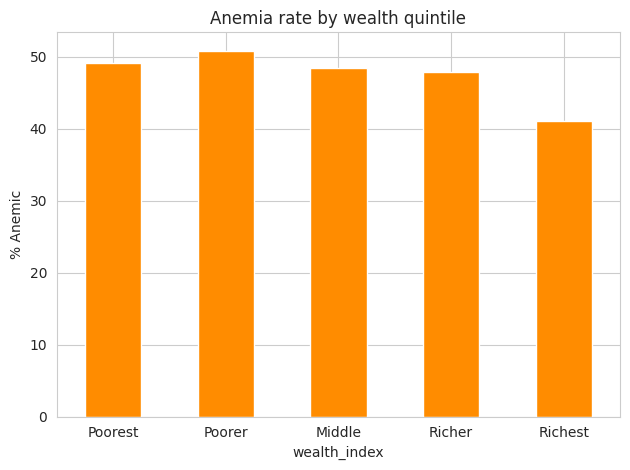

In [40]:
#Using Bar chart to show Anemia rate by wealth_index
wealth_rate.plot(kind='bar', color='darkorange')
plt.ylabel('% Anemic')
plt.title('Anemia rate by wealth quintile')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("anemia_by_wealth.png", dpi=300, bbox_inches="tight")
plt.show()

##Anemia prevalence differed across wealth groups, with the richest group showing the lowest observed prevalence. The analysis does not establish the mechanisms underlying this difference.

##Anemia_rate by Zone

In [41]:
#Anemi_rate by zone
zone = tested.groupby('zone', observed=True)['anemic'].mean() * 100
print("Anemia rate by zone quintile (%):")
print(zone.round(1))

Anemia rate by zone quintile (%):
zone
North Central    43.6
North East       49.0
North West       46.2
South East       54.0
South South      46.9
South West       46.7
Name: anemic, dtype: float64


In [42]:
zone_crosstab = pd.crosstab(tested['zone'], tested['anemic'])
print(zone_crosstab)

anemic            0     1
zone                     
North Central  1095   847
North East     1082  1039
North West     1576  1355
South East      846   994
South South     650   573
South West      531   465


In [43]:
chi2_stat, p_value, degrees_of_freedom, expected_counts = chi2_contingency(zone_crosstab)
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("This is statistically significant -- zone really is related to anemia.")
else:
    print("Not statistically significant -- could be due to chance.")

p-value: 0.0000
This is statistically significant -- zone really is related to anemia.


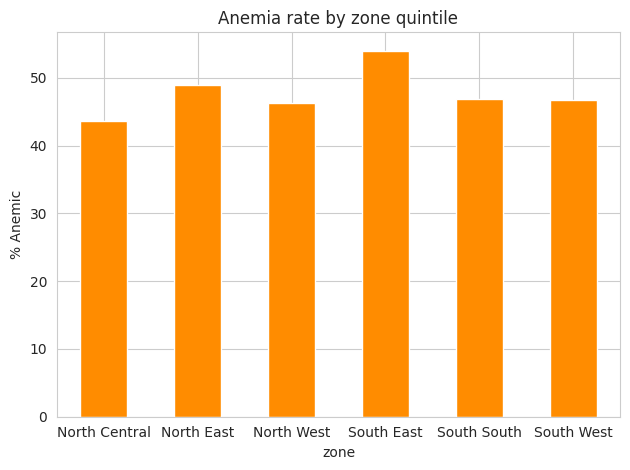

In [44]:
#Using Bar chart to show the Anemia _rate by zone
zone.plot(kind='bar', color='darkorange')
plt.ylabel('% Anemic')
plt.title('Anemia rate by zone quintile')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("anemia_by_zone_quintile.png", dpi=300, bbox_inches="tight")
plt.show()

##The South East recorded the highest observed anemia prevalence among the geographic zones examined.

##Anemia_rate by Urban/rural

In [45]:
#Anemia_rate by Urban/rural
urban_rural_rate = tested.groupby('urban_rural')['anemic'].mean().sort_values() * 100
print(urban_rural_rate.round(1))

urban_rural
Urban    45.2
Rural    49.4
Name: anemic, dtype: float64


In [46]:
#Using Chi_2 statistics
ur_crosstab = pd.crosstab(tested['urban_rural'], tested['anemic'])
chi2_stat, p_value, degrees_of_freedom, expected_counts = chi2_contingency(ur_crosstab)
print(f"p-value: {p_value:.4f}")

p-value: 0.0000


In [47]:
chi2_stat, p_value, degrees_of_freedom, expected_counts = chi2_contingency(zone_crosstab)
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("This is statistically significant -- urban_rural really is related to anemia.")
else:
    print("Not statistically significant -- could be due to chance.")

p-value: 0.0000
This is statistically significant -- urban_rural really is related to anemia.


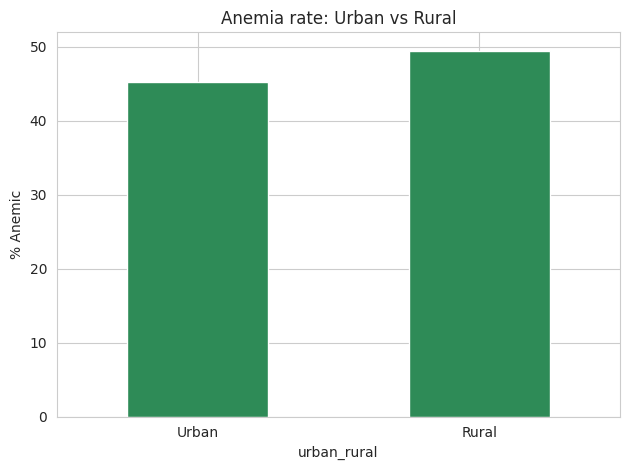

In [48]:
#Using Bar chat to show the Anemia_rate by Urban/rural
urban_rural_rate.plot(kind='bar', color='seagreen')
plt.ylabel('% Anemic')
plt.title('Anemia rate: Urban vs Rural')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("anemia_rate:urban vs rural.png", dpi=300, bbox_inches="tight")
plt.show()

##Observed anemia prevalence was higher among rural children than urban children

## Anemia_rate by BED NET OWNERSHIP and USE
Checking two related variables:
hh_net_ownership: does the household own a net at all?
child_net_use: did this specific child sleep under a net?

In [49]:
#Anemia_rate by bed_net_ownership
net_owner_rate = tested.groupby('hh_net_ownership')['anemic'].mean() * 100
print("By household net ownership (%):")
print(net_owner_rate.round(1))

By household net ownership (%):
hh_net_ownership
No     48.0
Yes    47.6
Name: anemic, dtype: float64


In [50]:
#Using chi_2 statistics
net_owner_crosstab = pd.crosstab(tested['hh_net_ownership'], tested['anemic'])
chi2_stat, p_value, degrees_of_freedom, expected_counts = chi2_contingency(net_owner_crosstab)
print(f"p-value (net ownership): {p_value:.4f}")

p-value (net ownership): 0.7009


In [51]:
#Anemia_rate by child_net_use
child_net_rate = tested.groupby('child_net_use', observed=True)['anemic'].mean() * 100
print("By child net use (%):")
print(child_net_rate.round(1))

By child net use (%):
child_net_use
Both treated and untreated    100.0
No net                         47.9
Not asked                      47.8
Only treated nets              47.0
Only untreated nets            53.3
Name: anemic, dtype: float64


In [52]:
#Using chi_2 statistics
child_net_crosstab = pd.crosstab(tested['child_net_use'], tested['anemic'])
chi2_stat, p_value, degrees_of_freedom, expected_counts = chi2_contingency(child_net_crosstab)
print(f"p-value (child net use): {p_value:.4f}")

p-value (child net use): 0.5514


##From my analysis, household_net_ownership and child_net_use are not strongly link to anemia because they have a p-value greater than 0.05..
It shows they are not statistically significant and could occur by random chance.

##Anemia_rate by fever

In [53]:
#Anemia_rate by had_fever
fever_rate = tested.groupby('had_fever', observed=True)['anemic'].mean() * 100
print(fever_rate.round(1))

had_fever
Don't know    50.0
No            47.8
Not tested    48.4
Yes           46.9
Name: anemic, dtype: float64


In [54]:
#Using chi_2 Statistics
fever_crosstab = pd.crosstab(tested['had_fever'], tested['anemic'])
chi2_stat, p_value, degrees_of_freedom, expected_counts = chi2_contingency(fever_crosstab)
print(f"p-value: {p_value:.4f}")

p-value: 0.8714


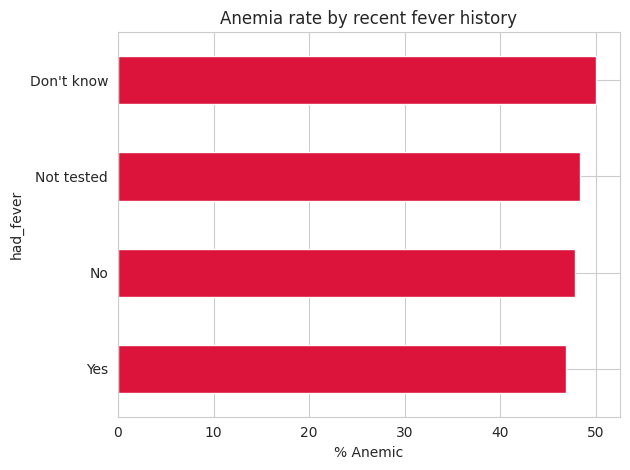

In [55]:
#Using bar chart
fever_rate.sort_values().plot(kind='barh', color='crimson')
plt.xlabel('% Anemic')
plt.title('Anemia rate by recent fever history')
plt.tight_layout()
plt.savefig("anemia_rate_ by_ recent_fever_history.png", dpi=300, bbox_inches="tight")
plt.show()

##From my analysis, recent fever history does not have a significant relationship with anemia because the p-value is greater than 0.05.
This is one of the limitations in my analysis by using indirect indicators.

##

##Preparing Features for Modeling..

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [57]:
#Chosen predictors
features = ["zone", "wealth_index","had_fever","urban_rural", "child_net_use","hh_net_ownership","birth_order"]
target = "anemic"

X = tested[features]
y = tested[target]

##All features except birth_order are categorical data.I use column transformer to apply onehotencoder ..

In [58]:
cat_cols = ['zone', 'urban_rural', 'wealth_index', 'had_fever',
            'hh_net_ownership', 'child_net_use']

In [59]:
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
    remainder='passthrough')

#80% train, 20% test. stratify=y keeps the same anemic/not ratio in both sets. random_state=42 makes the split reproducible.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 8842
Test size: 2211


#Train the Models


##This is a classification problem (predicting a category, not a number), so I  usetwo classifiers: Logistic Regression as an interpretable baseline, and Random Forestto check whether a more flexible model captures more signal.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [62]:
#Pipeline bundles preprocessing + model together so preprocessing is fit only on the training data, never leaking test data into it

logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
logreg_pipe.fit(X_train, y_train)

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42))
])
rf_pipe.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


##Trained models are Logistics regress and random forest classifier.

##Evaluating both models

##To check the accuracy of both models so i also look at precision/recall/F per class, the confusion matrix,AUC-ROC

In [63]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay

In [64]:
for name, pipe in [('Logistic Regression', logreg_pipe), ('Random Forest', rf_pipe)]:
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]  # probability of being anemic

    print(f"=== {name} ===")
    print(classification_report(y_test, preds, target_names=['Not anemic', 'Anemic']))
    print("AUC:", round(roc_auc_score(y_test, probs), 3))
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(confusion_matrix(y_test, preds))
    print()

=== Logistic Regression ===
              precision    recall  f1-score   support

  Not anemic       0.54      0.80      0.65      1156
      Anemic       0.55      0.26      0.35      1055

    accuracy                           0.54      2211
   macro avg       0.54      0.53      0.50      2211
weighted avg       0.54      0.54      0.51      2211

AUC: 0.559
Confusion matrix (rows=actual, cols=predicted):
[[925 231]
 [778 277]]

=== Random Forest ===
              precision    recall  f1-score   support

  Not anemic       0.54      0.79      0.64      1156
      Anemic       0.53      0.26      0.35      1055

    accuracy                           0.54      2211
   macro avg       0.54      0.53      0.50      2211
weighted avg       0.54      0.54      0.50      2211

AUC: 0.566
Confusion matrix (rows=actual, cols=predicted):
[[916 240]
 [782 273]]



##From my analysis both models perform only slightly better than random guessing (AUC ≈ 0.56, where 0.5 = pure chance).Accuracy sits around 54% for both. More importantly, the confusion matrix shows the model correctly identifies only about 26% of children who are actually anemic (277 out of 1,055 in the Logistic Regression test set), it misses far more true anemia cases than it catches.

##ROC Curve Comparison

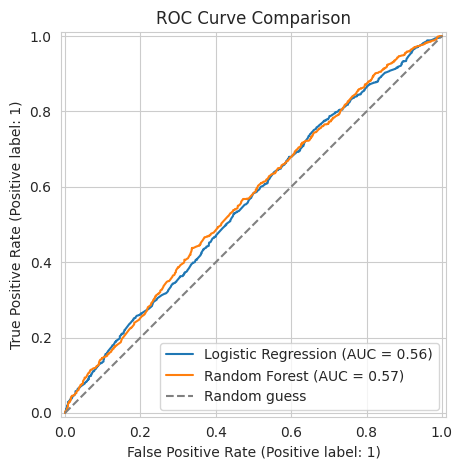

In [65]:
fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(logreg_pipe, X_test, y_test, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_estimator(rf_pipe, X_test, y_test, name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.savefig("ROC_Curve_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

##Both curves sit close to the gray diagonal (random guessing), matching the AUC scores above:Logistic Regression = 0.56, Random Forest = 0.57. The two models perform almost identically,showing the limit isn't the algorithm choice but weak predictive signal in the available features (zone, wealth, urban/rural, fever, net use). This confirms the classification report that  socio-demographic and behavioral variables in this dataset are not strong enough on their own to reliably predict individual anemia status.

##Feature Importance

##Which Variable drove the random forest predictions.

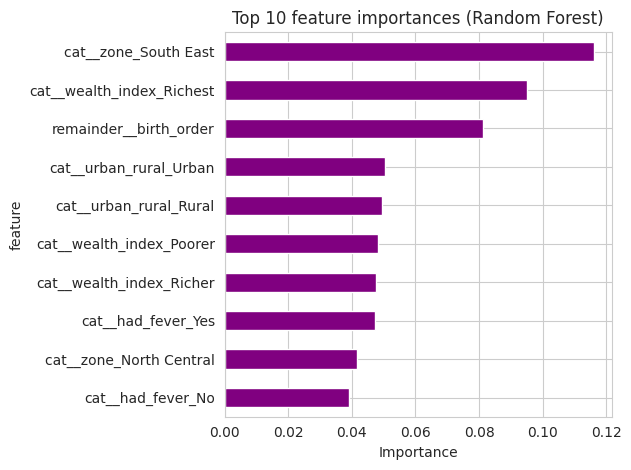

In [66]:

#using encoded feature names

feature_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipe.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances}).sort_values('importance', ascending=False)

top10 = importance_df.head(10).sort_values('importance')  # ascending for a horizontal bar chart
top10.plot(x='feature', y='importance', kind='barh', legend=False, color='purple')
plt.xlabel('Importance')
plt.title('Top 10 feature importances (Random Forest)')
plt.tight_layout()
plt.savefig("Top_10_fearure_importances.png", dpi=300, bbox_inches="tight")
plt.show()

##The Random Forest ranks which specific categories most influenced its predictions. The top three are zone_South East, wealth_index_Richest, and birth_order : meaning being in the South East zone, being in the richest wealth group, and a child's birth order carried the most weight in the model's decisions. This lines up with the EDA: zone and wealth were the two variables that showed a statistically significant relationship with anemia, so it makes sense the model leans on them most.

##From my analysis almost 60% of children were not tested for anemia..
Was testing biased?.

In [67]:
#Testing rate by zone
df['tested'] = (df['anemia_level'] != 'Not tested')

print("Testing rate by zone (%):")
print((df.groupby('zone')['tested'].mean() * 100).round(1))
print()

Testing rate by zone (%):
zone
North Central    38.4
North East       36.0
North West       34.1
South East       60.2
South South      45.8
South West       39.7
Name: tested, dtype: float64



##South East has the highest testing rate for anemia..

In [68]:
#Testing rate by wealth_indexprint("Testing rate by wealth index (%):")

print((df.groupby('wealth_index')['tested'].mean()*100).round(1))

wealth_index
Middle     40.6
Poorer     37.6
Poorest    35.3
Richer     45.0
Richest    42.9
Name: tested, dtype: float64


##Testing coverage varies modestly across wealth groups, from 35.3% (Poorest) to 45.0%(Richer).Richer households were somewhat more likely to have their child tested for anemia than poorer ones.

##severity breakdown by wealth_index. Which wealth_index  in the binary anemia rate hold  severe cases, or is it driven mostly by mild anemia?

In [69]:
severity_by_wealth = pd.crosstab(
    tested['wealth_index'], tested['anemia_level'], normalize='index'
) * 100

In [70]:
#Reorder columns from healthiest to most severe for a readable table
severity_by_wealth = severity_by_wealth[['Not anemic', 'Mild', 'Moderate', 'Severe']]
severity_by_wealth.round(1)

anemia_level,Not anemic,Mild,Moderate,Severe
wealth_index,,,,
Poorest,50.8,22.5,24.8,1.9
Poorer,49.1,25.4,24.9,0.6
Middle,51.5,25.0,22.6,0.9
Richer,52.1,29.0,18.2,0.6
Richest,58.9,24.1,16.8,0.1


## From my analysis,Poorest has the highest cases of severe anemia

##Does the wealth effect differ by urban/rural?
Checks for an interaction: is being in a poorer household "worse" in rural areas
than in urban ones, or is the wealth effect consistent everywhere

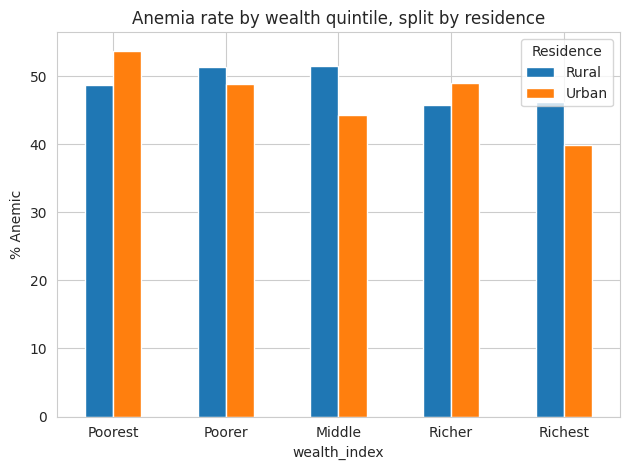

In [71]:
interaction = tested.groupby(
    ['urban_rural', 'wealth_index'], observed=True
)['anemic'].mean().unstack() * 100

interaction.T.plot(kind='bar')
plt.ylabel('% Anemic')
plt.title('Anemia rate by wealth quintile, split by residence')
plt.xticks(rotation=0)
plt.legend(title='Residence')
plt.tight_layout()
plt.savefig("Anemia_rate_by_wealth_quintile,split_by_residence.png", dpi=300, bbox_inches="tight")
plt.show()

##From the chart,the gap between urban and rural isn't constant across wealth levels.This suggests wealth and residence interact rather than acting independently.

##Conclusion

This analysis found substantial variation in observed childhood anemia prevalence across wealth groups, geographic zones and urban/rural residence in the children with available anemia measurements.

Wealth and geographic zone showed statistically significant associations with anemia, while bed-net variables and recent fever history did not show significant associations in this analysis.

However, the machine learning models performed poorly, with AUC values of approximately 0.56–0.57. This suggests that the selected socioeconomic, demographic and behavioral variables alone do not contain enough information to reliably predict individual anemia status.

The main lesson from the project is simple: finding an association is not the same as being able to make a useful prediction.